# Import Libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load Dataset

In [3]:
df = pd.read_csv("final_merged_all_models_updated.csv")

# Define Model Columns

In [4]:
model_columns = [
    "gpt4o_abstractive_summary",
    "gemini_abstractive_summary",
    "llama_abstractive_summary",
    "deepseek_abstractive_summary",
    "mistral_abstractive_summary",
    "claude_abstractive_summary"
]

# Initialize VADER

In [5]:
analyzer = SentimentIntensityAnalyzer()

# TextBlob Sentiment Function

In [ ]:
def textblob_sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

# VADER Sentiment Function

In [6]:
def get_vader_sentiment(text):

    score = analyzer.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Compute Sentiment Counts (TextBlob)

In [19]:
tb_results = {}

for model in model_columns:

    sentiments = df[model].apply(textblob_sentiment)

    counts = sentiments.value_counts()

    tb_results[model] = {
        "Positive": counts.get("Positive",0),
        "Neutral": counts.get("Neutral",0),
        "Negative": counts.get("Negative",0)
    }

textblob_df = pd.DataFrame(tb_results).T

textblob_df

,Positive,Neutral,Negative
gpt4o_abstractive_summary,279,404,100
gemini_abstractive_summary,250,450,83
llama_abstractive_summary,249,369,165
deepseek_abstractive_summary,228,427,128
mistral_abstractive_summary,240,428,115
claude_abstractive_summary,238,487,58


# Compute Sentiment Counts (VADER)

In [7]:
sentiment_results = {}

for model in model_columns:

    sentiments = df[model].apply(get_vader_sentiment)

    counts = sentiments.value_counts()

    sentiment_results[model] = {
        "Positive": counts.get("Positive",0),
        "Neutral": counts.get("Neutral",0),
        "Negative": counts.get("Negative",0)
    }

sentiment_df = pd.DataFrame(sentiment_results).T

sentiment_df

,Positive,Neutral,Negative
gpt4o_abstractive_summary,392,19,372
gemini_abstractive_summary,393,19,371
llama_abstractive_summary,338,22,423
deepseek_abstractive_summary,326,26,431
mistral_abstractive_summary,359,28,396
claude_abstractive_summary,424,20,339


# TextBlob Sentiment Graph

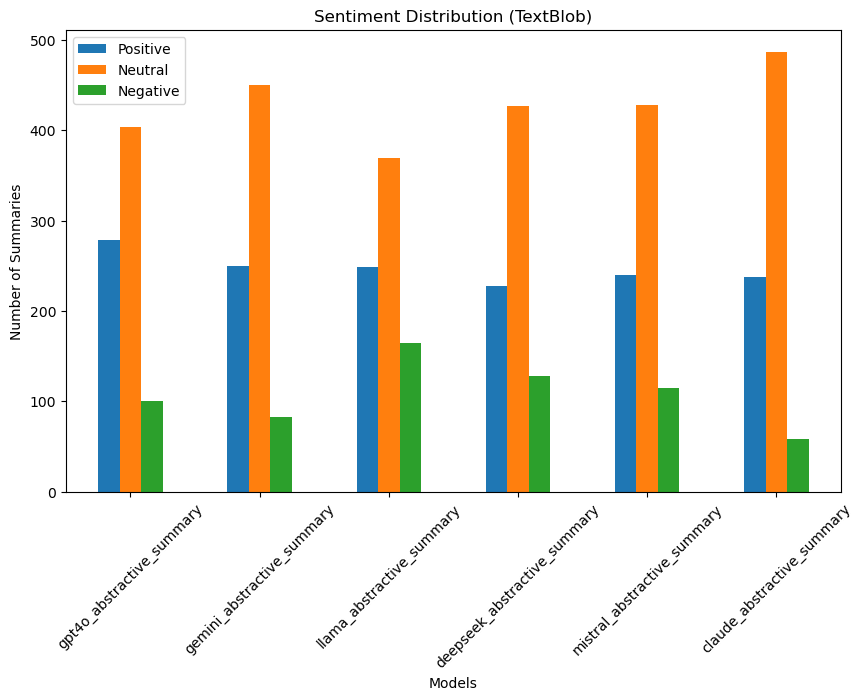

In [20]:
textblob_df.plot(kind="bar", figsize=(10,6))

plt.title("Sentiment Distribution (TextBlob)")
plt.xlabel("Models")
plt.ylabel("Number of Summaries")

plt.xticks(rotation=45)

plt.show()

# VADER Sentiment Graph

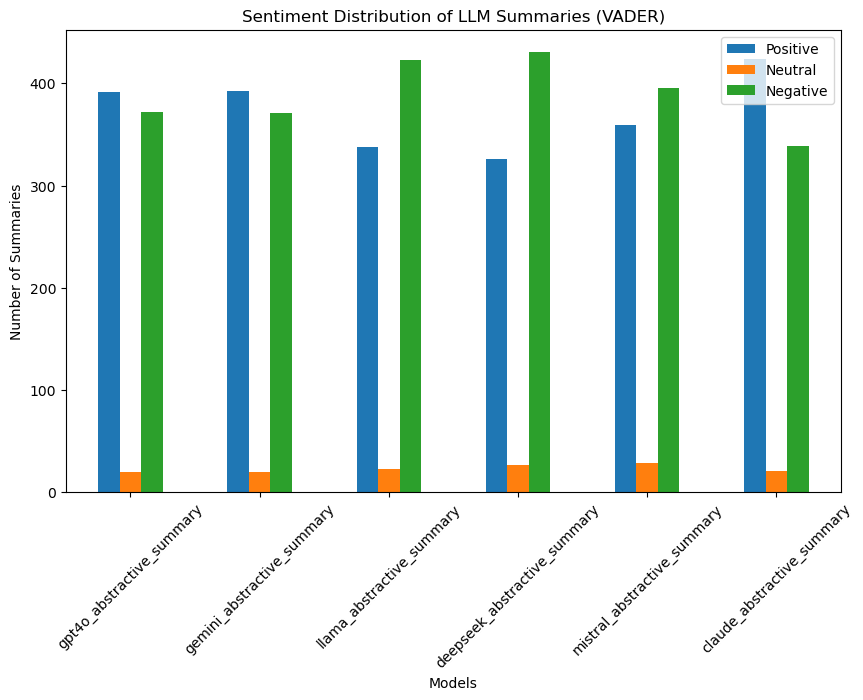

In [8]:
sentiment_df.plot(kind="bar", figsize=(10,6))

plt.title("Sentiment Distribution of LLM Summaries (VADER)")
plt.xlabel("Models")
plt.ylabel("Number of Summaries")

plt.xticks(rotation=45)

plt.show()

# Percentage Comparison

In [22]:
tb_percent = textblob_df.div(textblob_df.sum(axis=1), axis=0) * 100
vd_percent = vader_df.div(vader_df.sum(axis=1), axis=0) * 100

tb_percent

,Positive,Neutral,Negative
gpt4o_abstractive_summary,35.632184,51.596424,12.771392
gemini_abstractive_summary,31.928480,57.471264,10.600255
llama_abstractive_summary,31.800766,47.126437,21.072797
deepseek_abstractive_summary,29.118774,54.533844,16.347382
mistral_abstractive_summary,30.651341,54.661558,14.687101
claude_abstractive_summary,30.395913,62.196679,7.407407


In [31]:
vd_percent

,Positive,Neutral,Negative
gpt4o_abstractive_summary,50.063857,2.426564,47.509579
gemini_abstractive_summary,50.191571,2.426564,47.381865
llama_abstractive_summary,43.167305,2.809706,54.022989
deepseek_abstractive_summary,41.634738,3.320562,55.044700
mistral_abstractive_summary,45.849298,3.575990,50.574713
claude_abstractive_summary,54.150702,2.554278,43.295019


# Side-by-Side Comparison Graph

In [23]:
comparison = pd.concat(
    [tb_percent.add_suffix("_TB"), vd_percent.add_suffix("_VADER")],
    axis=1
)

comparison

,Positive_TB,Neutral_TB,Negative_TB,Positive_VADER,Neutral_VADER,Negative_VADER
gpt4o_abstractive_summary,35.632184,51.596424,12.771392,50.063857,2.426564,47.509579
gemini_abstractive_summary,31.928480,57.471264,10.600255,50.191571,2.426564,47.381865
llama_abstractive_summary,31.800766,47.126437,21.072797,43.167305,2.809706,54.022989
deepseek_abstractive_summary,29.118774,54.533844,16.347382,41.634738,3.320562,55.044700
mistral_abstractive_summary,30.651341,54.661558,14.687101,45.849298,3.575990,50.574713
claude_abstractive_summary,30.395913,62.196679,7.407407,54.150702,2.554278,43.295019


# Comparison Graph text blob and vader

In [25]:
comparison_df = pd.DataFrame({
    "TextBlob_Positive": textblob_df["Positive"],
    "VADER_Positive": vader_df["Positive"],
    "TextBlob_Neutral": textblob_df["Neutral"],
    "VADER_Neutral": vader_df["Neutral"],
    "TextBlob_Negative": textblob_df["Negative"],
    "VADER_Negative": vader_df["Negative"]
})

comparison_df

,TextBlob_Positive,VADER_Positive,TextBlob_Neutral,VADER_Neutral,TextBlob_Negative,VADER_Negative
gpt4o_abstractive_summary,279,392,404,19,100,372
gemini_abstractive_summary,250,393,450,19,83,371
llama_abstractive_summary,249,338,369,22,165,423
deepseek_abstractive_summary,228,326,427,26,128,431
mistral_abstractive_summary,240,359,428,28,115,396
claude_abstractive_summary,238,424,487,20,58,339


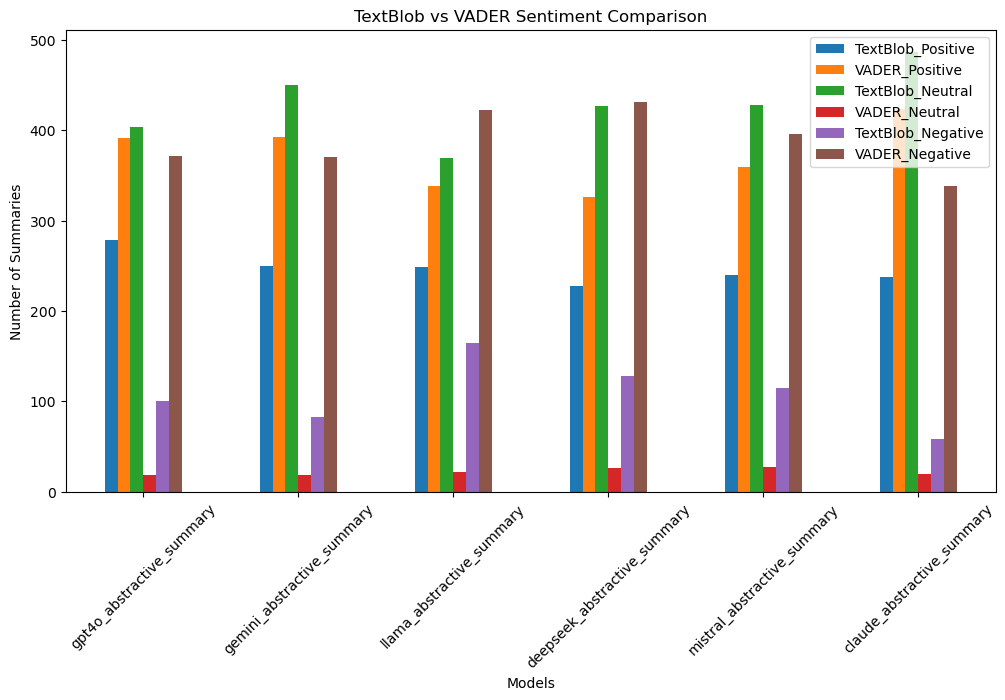

In [26]:
comparison_df.plot(kind="bar", figsize=(12,6))

plt.title("TextBlob vs VADER Sentiment Comparison")
plt.ylabel("Number of Summaries")
plt.xlabel("Models")

plt.xticks(rotation=45)

plt.show()

# Difference Between Methods

In [27]:
difference_df = vader_df - textblob_df

difference_df

,Positive,Neutral,Negative
gpt4o_abstractive_summary,113,-385,272
gemini_abstractive_summary,143,-431,288
llama_abstractive_summary,89,-347,258
deepseek_abstractive_summary,98,-401,303
mistral_abstractive_summary,119,-400,281
claude_abstractive_summary,186,-467,281


# Difference Graph

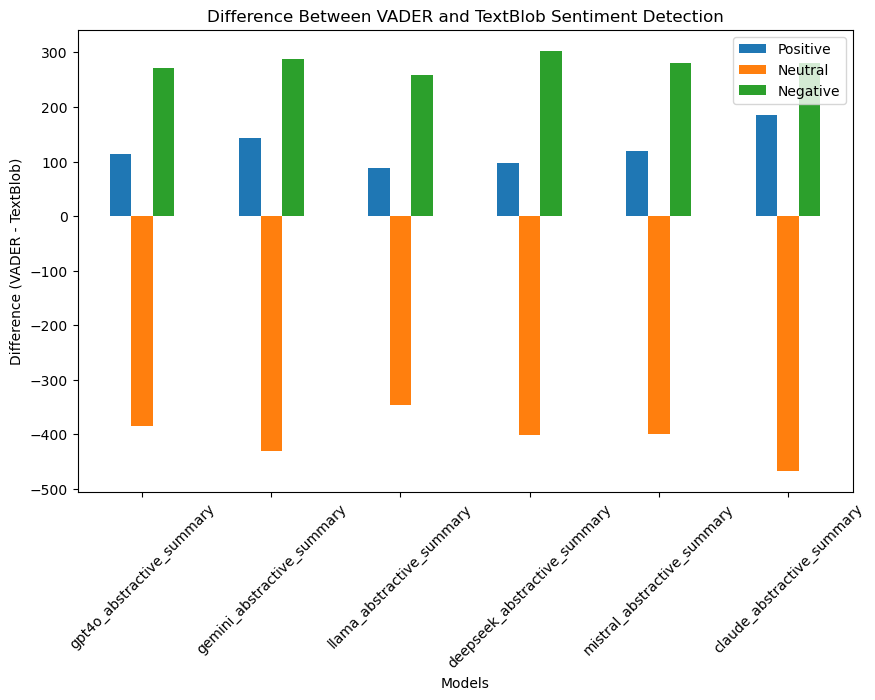

In [30]:
difference_df.plot(kind="bar", figsize=(10,6))

plt.title("Difference Between VADER and TextBlob Sentiment Detection")
plt.ylabel("Difference (VADER - TextBlob)")
plt.xlabel("Models")

plt.xticks(rotation=45)

plt.show()